# Market Differentiated Bars

## Process the Data

- **Purpose:** Apply fixed-width fractional differencing to dollar-bar log close prices.
- **Settings:** `weight_cutoff=0.01`; `d=0.0,0.1,…,1.0`; ADF 5% critical value; `maxlag=1`, `regression=c`, `autolag=None`.
- **Data:** Dollar-bar log close prices produce one persisted fractionally differenced feature.
- **Findings:**
- **Decision:** Select the smallest tested `d` that passes the ADF critical value using January 2025 preparation data only.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.preprocessing.market_data import ResearchPaths

PROJECT_ROOT = Path.cwd().resolve().parents[1]
PERIOD = "2025-02-01_2025-12-31"
MANIFEST_PATH = PROJECT_ROOT / "data/preprocessing/universe/sp500_2025.csv"
EXPECTED_SECURITIES = 503
RESEARCH_START = pd.Timestamp("2025-02-01", tz="UTC")
WEIGHT_CUTOFF = 0.01
DIFFERENCING_ORDERS = np.linspace(0, 1, 11).tolist()
ADF_MAXLAG = 1
ADF_REGRESSION = "c"
ADF_AUTOLAG = None
ADF_SIGNIFICANCE = "5%"
paths = ResearchPaths(PROJECT_ROOT, period=PERIOD)
DISPLAY_SYMBOL = "AAPL"  # Inspection only; every manifest symbol is processed.

from src.preprocessing.market_differentiated_bars import build_fractional_features
started = perf_counter()
fractional_report = build_fractional_features(
    paths,
    manifest_path=MANIFEST_PATH,
    expected_securities=EXPECTED_SECURITIES,
    fit_end=RESEARCH_START,
    weight_cutoff=WEIGHT_CUTOFF,
    differencing_orders=DIFFERENCING_ORDERS,
    adf_maxlag=ADF_MAXLAG,
    adf_regression=ADF_REGRESSION,
    adf_autolag=ADF_AUTOLAG,
    adf_significance=ADF_SIGNIFICANCE,
    show_progress=True,
)
elapsed_seconds = perf_counter() - started
cached = fractional_report["status"].eq("cached")
display(pd.Series({
    "completed_symbols": len(fractional_report),
    "processed_symbols": (~cached).sum(),
    "cached_symbols": cached.sum(),
    "processed_rows": fractional_report.loc[~cached].get("rows", pd.Series(dtype=float)).sum(),
    "elapsed_seconds": elapsed_seconds,
}))
display(fractional_report.head(5))
fractional_path = paths.feature(DISPLAY_SYMBOL, "fractional")
fractional_bars = pd.read_parquet(fractional_path)
fractional_path

Fractional features:   0%|          | 0/503 [00:00<?, ?it/s]

completed_symbols    5.030000e+02
processed_symbols    4.860000e+02
cached_symbols       1.700000e+01
processed_rows       4.815373e+07
elapsed_seconds      7.498940e+01
dtype: float64

,symbol,status,d,fit_end,rows
0,A,cached,NaN,NaT,NaN
1,AAPL,cached,NaN,NaT,NaN
2,ABBV,cached,NaN,NaT,NaN
3,ABNB,cached,NaN,NaT,NaN
4,ABT,cached,NaN,NaT,NaN


PosixPath('/Users/kwonjunhyuk9/Documents/financial-machine-learning/data/preprocessing/market/stock/AAPL/features/fractional.parquet')

## Take a Quick Look at the Data Structure

- **Purpose:** Inspect timestamps, dtype, range, and distribution of the persisted fractionally differenced feature.
- **Settings:**
- **Data:** Inspect the existing fractionally differenced feature artifact.
- **Findings:**
- **Decision:** Do not recalculate the feature or replace the selected differencing order.

In [2]:
fractional_bars.head()

,end,fractionally_differenced_log_close,symbol
0,2025-01-03 14:35:19.114491+00:00,2.039790,AAPL
1,2025-01-03 14:35:30.980380+00:00,2.038932,AAPL
2,2025-01-03 14:35:46.747037+00:00,2.039737,AAPL
3,2025-01-03 14:36:12.017344+00:00,2.039134,AAPL
4,2025-01-03 14:36:35.742090+00:00,2.040192,AAPL


In [3]:
fractional_bars.info()

<class 'pandas.DataFrame'>
RangeIndex: 100668 entries, 0 to 100667
Data columns (total 3 columns):
 #   Column                              Non-Null Count   Dtype              
---  ------                              --------------   -----              
 0   end                                 100668 non-null  datetime64[us, UTC]
 1   fractionally_differenced_log_close  100668 non-null  float64            
 2   symbol                              100668 non-null  str                
dtypes: datetime64[us, UTC](1), float64(1), str(1)
memory usage: 2.7 MB


In [4]:
fractional_bars.dtypes.value_counts()

datetime64[us, UTC]    1
float64                1
str                    1
Name: count, dtype: int64

In [5]:
fractional_bars[["fractionally_differenced_log_close"]].describe()

,fractionally_differenced_log_close
count,100668.000000
mean,2.018217
std,0.042947
min,1.884612
25%,1.983394
50%,2.018595
75%,2.049445
max,2.106955


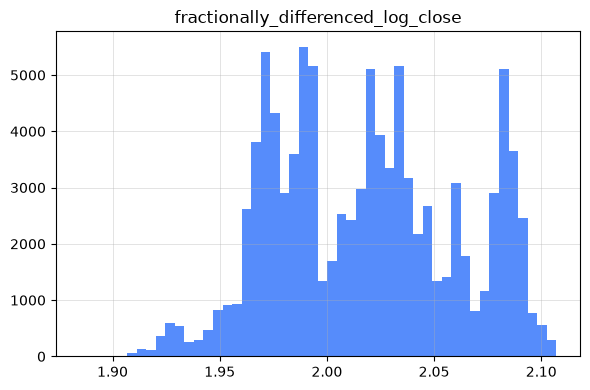

In [6]:
fractional_bars[["fractionally_differenced_log_close"]].hist(
    bins=50, figsize=(6, 4)
)
plt.tight_layout()
plt.show()